In [1]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 7.1/351.2 MB 36.0 MB/s eta 0:00:10
   - -------------------------------------- 12.3/351.2 MB 30.6 MB/s eta 0:00:12
   -- ------------------------------------- 18.1/351.2 MB 29.0 MB/s eta 0:00:12
   -- ------------------------------------- 23.3/351.2 MB 28.3 MB/s eta 0:00:12
   --- ------------------------------------ 29.1/351.2 MB 27.8 MB/s eta 0:00:12
   --- ------------------------------------ 34.6/351.2 MB 27.6 MB/s eta 0:00:12
   ---- ----------------------------------- 40.1/351.2 MB 27.4 MB/s eta 0:00:12
   ----- ---------------------------------- 45.4/351.2 MB 27.3 MB/s eta 0:00:12
   ----- ---------------------------------- 50.9/351.2 MB 27.1 MB/s eta 0:00:12
   ------ --------------------------------- 56.4/351.2 MB 27.0 MB/s eta 0:00:11
   ------- -------------------------------- 61.6/351.2 MB 27.0 MB/s eta 0:00:11
   ------- -------------------------------- 67.1/3

Accuracy: 100.00%


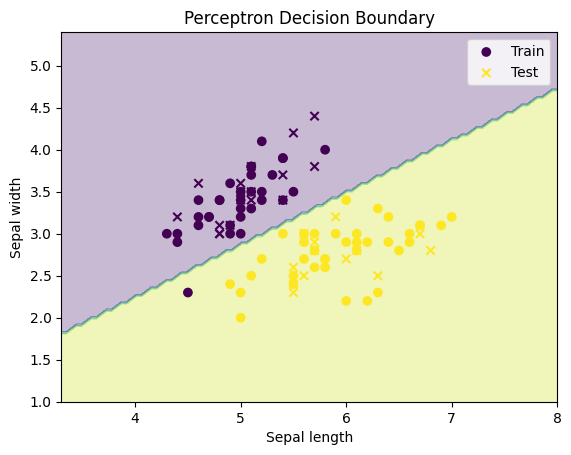

In [7]:
# 1) Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 2) Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# For simplicity, only take classes 0 and 1 (Setosa vs Versicolor)
mask = y < 2
X = X[mask]
y = y[mask]

# Only use two features: sepal length and sepal width
X = X[:, :2]

# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4) Create & fit Perceptron
clf = Perceptron(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# 5) Predict
y_pred = clf.predict(X_test)

# 6) Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

# 7) Plot decision boundary
xmin, xmax = X[:, 0].min() - 1, X[:, 0].max() + 1
ymin, ymax = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100),
                     np.linspace(ymin, ymax, 100))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, label="Train")
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=y_test, label="Test")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.show()

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load dataset (MNIST)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to include channel dimension (28x28 → 28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Build CNN model
model = models.Sequential()

# Convolution + Pooling layers
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten layer
model.add(layers.Flatten())

# Fully connected layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=5, batch_size=32)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


c:\Users\keval\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9565 - loss: 0.1393
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9855 - loss: 0.0468
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9901 - loss: 0.0325
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9927 - loss: 0.0233
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9941 - loss: 0.0175
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9908 - loss: 0.0282
Test Accuracy: 0.9908000230789185


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data     # features
y = data.target   # labels (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = models.Sequential()

model.add(layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=16)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


Epoch 1/20


c:\Users\keval\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5956 - loss: 0.7260   
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7582 - loss: 0.5323 
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8879 - loss: 0.3760 
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9363 - loss: 0.2772 
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9538 - loss: 0.2152 
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9626 - loss: 0.1745 
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9692 - loss: 0.1468 
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9714 - loss: 0.1271 
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9714 - loss: 0.1121 
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9736 - loss: 0.1010 
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9802 - loss: 0.0923 
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9802 - 